In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2024-12-11 18:49:05**

https://www.analyticsvidhya.com/blog/2022/04/predicting-possible-loan-default-using-machine-learning/

In [ ]:
import numpy as np  # Importing numpy library and aliasing it as 'np' for convenience`
import pandas as pd  # Importing pandas library and aliasing it as 'pd' for convenience
import matplotlib.pyplot as plt  # Importing matplotlib library for plotting graphs
import seaborn as sns  # Importing seaborn library for data visualization


# If you want to upload a file directly to Colab, you can use the following code:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(io.StringIO(uploaded['YourFile.csv'].decode('utf-8')))

# Now you can use the data in your DataFrame (df) and proceed with the rest of your analysis.

# Set seaborn theme and display plots inline
sns.set_theme(style="darkgrid")
%matplotlib inline


In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/9394113857/Loan-Prediction-Code/main/Training%20Data.csv")  # Reading the CSV file into a DataFrame


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [ ]:
data.head()  # Displaying the first few rows of the DataFrame


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


# Understanding the data set

In [ ]:
# Get the number of rows and columns in the DataFrame
rows, columns = data.shape

# Print the number of rows and columns
print('Rows:', rows)
print('Columns:', columns)


Rows: 252000
Columns: 13


In [ ]:
# Display information about the DataFrame, including data types and memory usage
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [ ]:
# Check for missing values in each column and display the total count of missing values
data.isnull().sum()


,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


In [ ]:
# Display the column names of the DataFrame
data.columns


Index(['Id', 'Income', 'Age', 'Experience', 'Married/Single',
       'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE',
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag'],
      dtype='object')

# Analysing Numerical columns

In [ ]:
# Display summary statistics of the numerical columns in the DataFrame
data.describe()


,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [ ]:
# # Calculate the correlation matrix of the numerical columns in the DataFrame
# data.corr()


In [ ]:
# Select only the numerical columns from the DataFrame
numerical_data = data.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix for the numerical columns
correlation_matrix = numerical_data.corr()

# Display the correlation matrix
correlation_matrix


,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
Id,1.000000,-0.001324,-0.001816,-0.005810,-0.003250,0.001972,0.032153
Income,-0.001324,1.000000,-0.000652,0.006422,0.007045,-0.002397,-0.003091
Age,-0.001816,-0.000652,1.000000,-0.001118,0.002154,-0.020134,-0.021809
Experience,-0.005810,0.006422,-0.001118,1.000000,0.646098,0.019309,-0.034523
CURRENT_JOB_YRS,-0.003250,0.007045,0.002154,0.646098,1.000000,0.005372,-0.016942
CURRENT_HOUSE_YRS,0.001972,-0.002397,-0.020134,0.019309,0.005372,1.000000,-0.004375
Risk_Flag,0.032153,-0.003091,-0.021809,-0.034523,-0.016942,-0.004375,1.000000


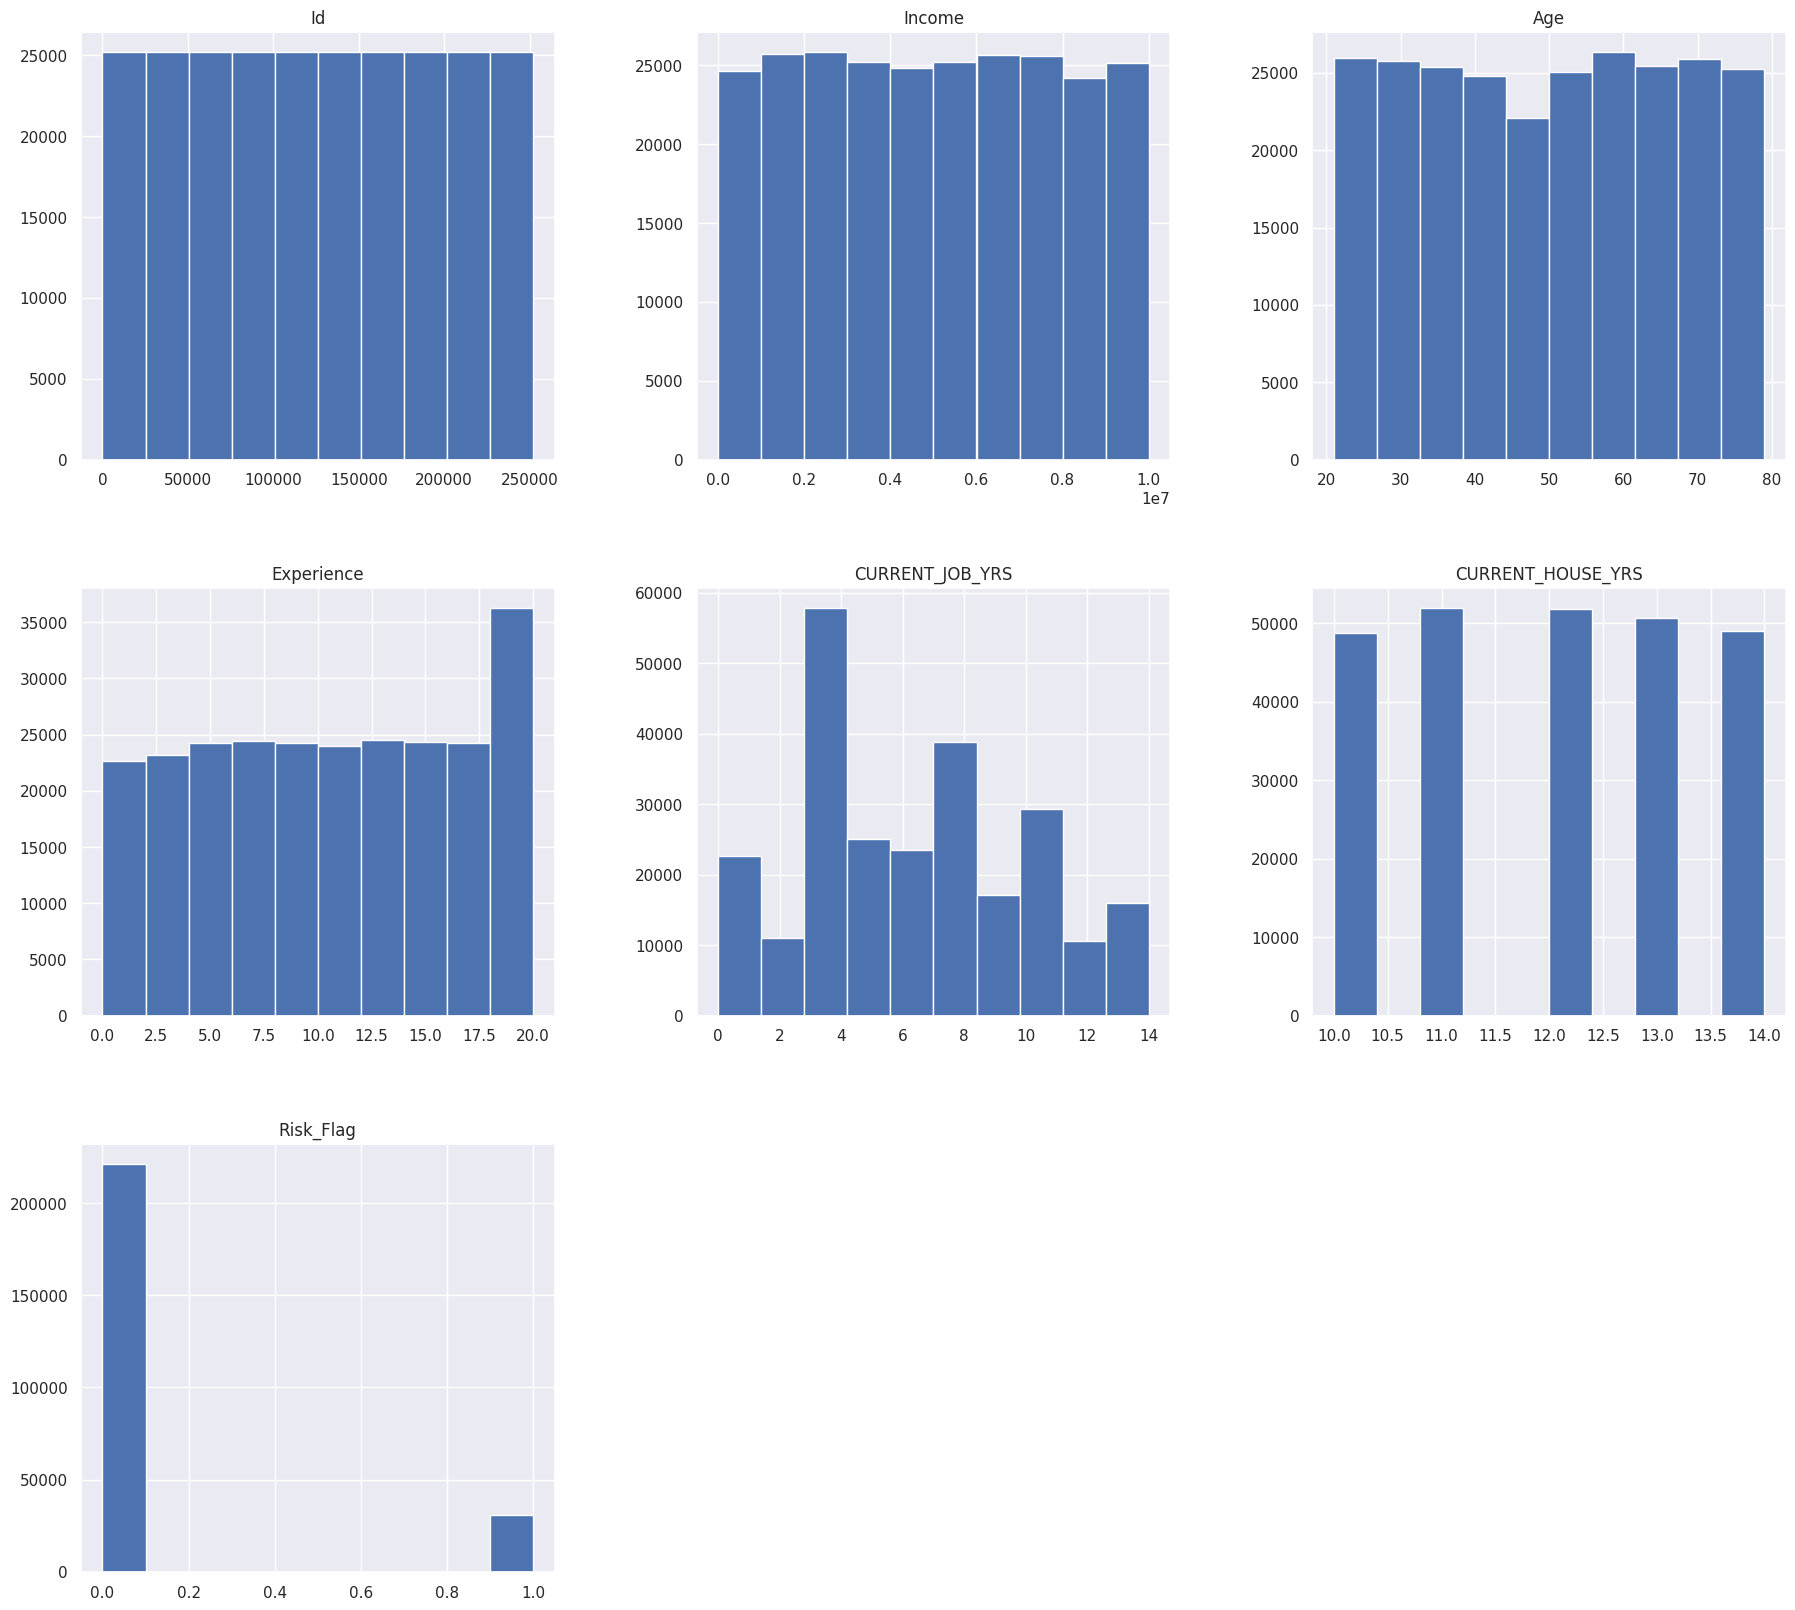

In [ ]:
# Display histograms for all numerical columns in the DataFrame
data.hist(figsize=(22, 20))
plt.show()


In [ ]:
# Count the number of occurrences of each unique value in the 'Risk_Flag' column
data["Risk_Flag"].value_counts()


,count
Risk_Flag,
0,221004
1,30996


In [ ]:
# # Create subplots with a specified size
# fig, ax = plt.subplots(figsize=(12, 8))

# # Calculate the correlation matrix
# corr_matrix = data.corr()

# # Create a heatmap of the correlation matrix
# corr_heatmap = sns.heatmap(corr_matrix, cmap="flare", annot=True, ax=ax, annot_kws={"size": 14})

# # Display the heatmap
# plt.show()

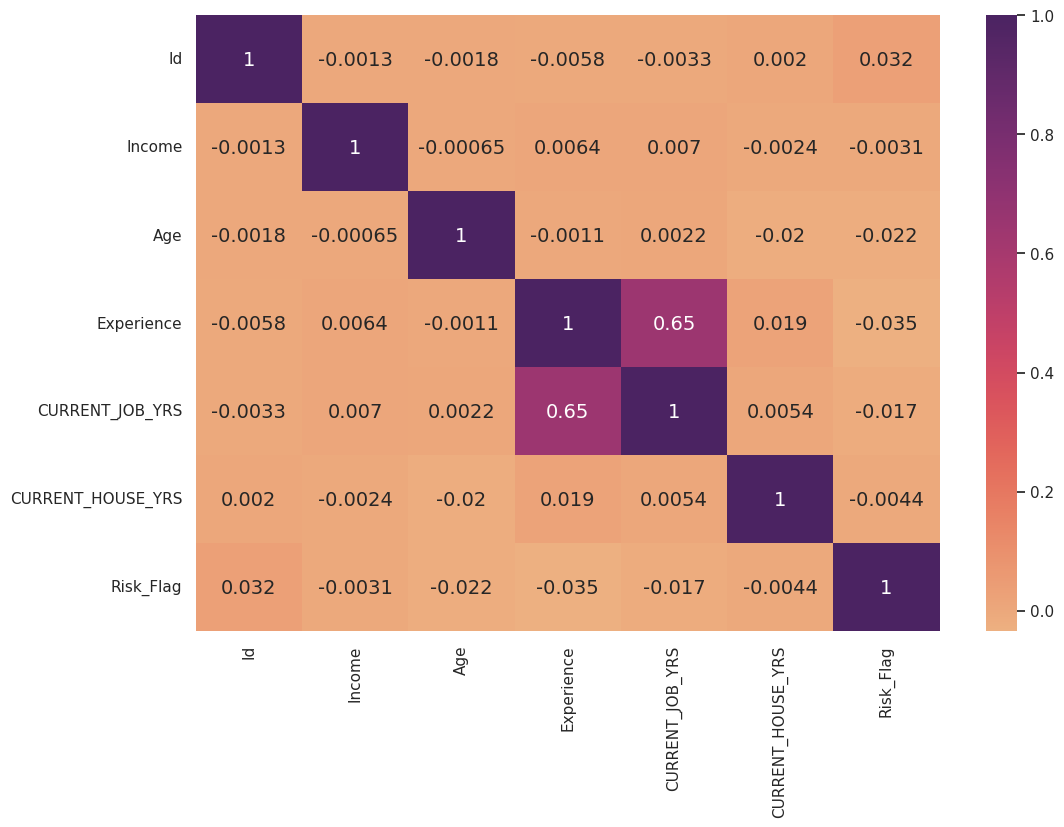

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numerical columns from the DataFrame
numerical_data = data.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix for the numerical columns
corr_matrix = numerical_data.corr()

# Create subplots with a specified size
fig, ax = plt.subplots(figsize=(12, 8))

# Create a heatmap of the correlation matrix
corr_heatmap = sns.heatmap(corr_matrix, cmap="flare", annot=True, ax=ax, annot_kws={"size": 14})

# Display the heatmap
plt.show()


**Points:**

1.	A heatmap is a graphical representation of data in which values are represented as colors.
2.	In this code, we use seaborn's heatmap function to create a heatmap of the correlation matrix.
3.	The correlation matrix is calculated using the corr() method on the DataFrame.
4.	We specify the colormap as "flare" to choose the color palette for the heatmap.
5.	The annot=True parameter adds annotations (correlation values) to each cell in the heatmap.
6.	The annot_kws={"size": 14} parameter adjusts the font size of the annotations for better readability.
7.	Finally, we display the heatmap using plt.show().



# Analysing the Categorical features

In [ ]:
def categorical_valcount_hist(feature):
    # Print the value counts of the specified feature
    print(data[feature].value_counts())

    # Create subplots with a specified size
    fig, ax = plt.subplots(figsize=(6, 6))

    # Create a countplot for the specified feature
    sns.countplot(x=feature, ax=ax, data=data)

    # Display the plot
    plt.show()


**Points:**

1.	This function categorical_valcount_hist takes a categorical feature as input and performs two tasks.
2.	It prints the value counts of the specified feature using the value_counts() method.
3.	Then, it creates a countplot to visualize the distribution of values of the specified feature using seaborn's countplot function.
4.	Finally, it displays the plot using plt.show().
5.	This function can be used to quickly visualize the distribution of categorical variables in the dataset.



Married/Single
single     226272
married     25728
Name: count, dtype: int64


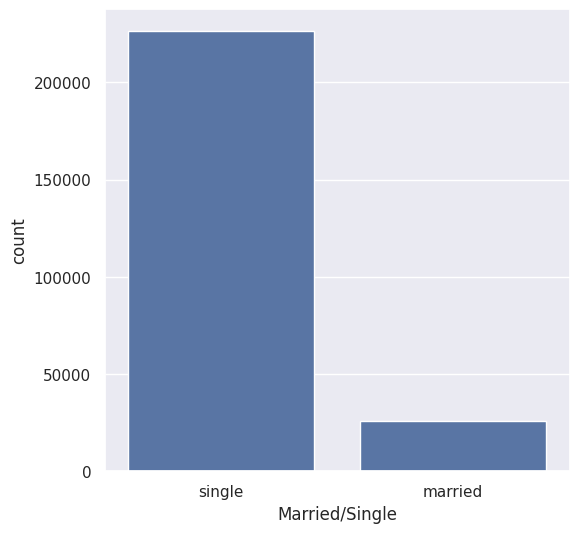

In [ ]:
categorical_valcount_hist("Married/Single")

House_Ownership
rented          231898
owned            12918
norent_noown      7184
Name: count, dtype: int64


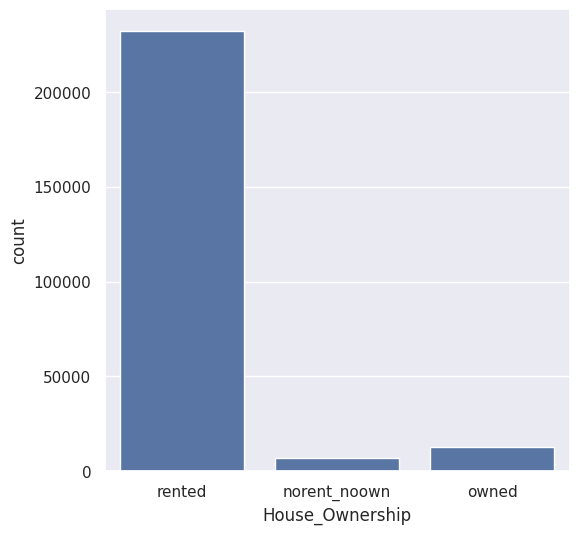

In [ ]:
categorical_valcount_hist("House_Ownership")

In [ ]:
# Print the total number of unique categories in the "STATE" column of the data
print("Total categories in STATE:", len(data["STATE"].unique()))

# Print a blank line for separation
print()

# Print the count of each unique category in the "STATE" column
print(data["STATE"].value_counts())


Total categories in STATE: 29

STATE
Uttar_Pradesh        28400
Maharashtra          25562
Andhra_Pradesh       25297
West_Bengal          23483
Bihar                19780
Tamil_Nadu           16537
Madhya_Pradesh       14122
Karnataka            11855
Gujarat              11408
Rajasthan             9174
Jharkhand             8965
Haryana               7890
Telangana             7524
Assam                 7062
Kerala                5805
Delhi                 5490
Punjab                4720
Odisha                4658
Chhattisgarh          3834
Uttarakhand           1874
Jammu_and_Kashmir     1780
Puducherry            1433
Mizoram                849
Manipur                849
Himachal_Pradesh       833
Tripura                809
Uttar_Pradesh[5]       743
Chandigarh             656
Sikkim                 608
Name: count, dtype: int64


**Points:**

1.	Utilizes len() function to find the count of unique categories in the "STATE" column.
2.	Utilizes value_counts() method to count the occurrences of each unique category in the "STATE" column.



In [ ]:
# Print the total number of unique categories in the "Profession" column of the data
print("Total categories in Profession:", len(data["Profession"].unique()))

# Print a blank line for separation
print()

# Print the count of each unique category in the "Profession" column
data["Profession"].value_counts()


Total categories in Profession: 51



,count
Profession,
Physician,5957
Statistician,5806
Web_designer,5397
Psychologist,5390
Computer_hardware_engineer,5372
Drafter,5359
Magistrate,5357
Fashion_Designer,5304
Air_traffic_controller,5281


**Points:**

1.	Utilizes len() function to find the count of unique categories in the "Profession" column.
2.	Utilizes value_counts() method to count the occurrences of each unique category in the "Profession" column.



# Data Analysis

In [ ]:
# Display concise summary of the DataFrame
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


<Axes: xlabel='Risk_Flag', ylabel='Income'>

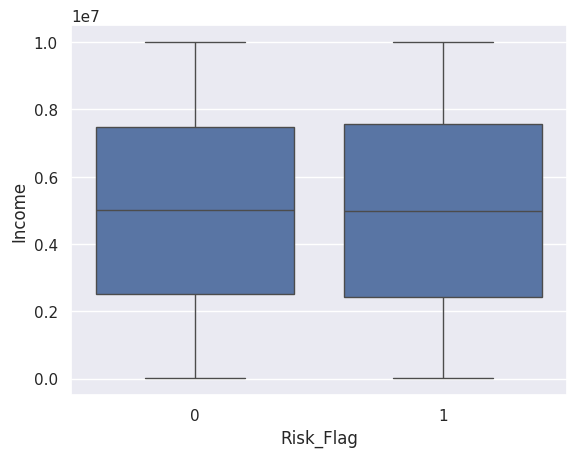

In [ ]:
# Create a boxplot to visualize the distribution of "Income" based on "Risk_Flag"
sns.boxplot(x="Risk_Flag", y="Income", data=data)


**Points:**

1.	Utilizes sns.boxplot() function to create a boxplot.
2.	Specifies the "Risk_Flag" column as the x-axis and the "Income" column as the y-axis.
3.	Uses the DataFrame data as the data source.



<Axes: xlabel='Risk_Flag', ylabel='Age'>

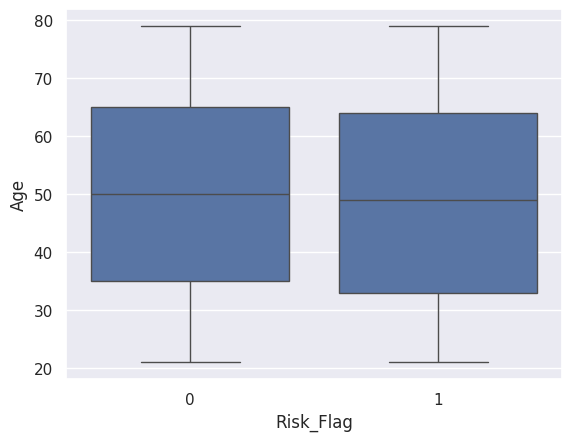

In [ ]:
# Create a boxplot to visualize the distribution of "Age" based on "Risk_Flag"
sns.boxplot(x="Risk_Flag", y="Age", data=data)


**Points:**

1.	Utilizes sns.boxplot() function to create a boxplot.
2.	Specifies the "Risk_Flag" column as the x-axis and the "Age" column as the y-axis.
3.	Uses the DataFrame data as the data source.



<Axes: xlabel='Risk_Flag', ylabel='Experience'>

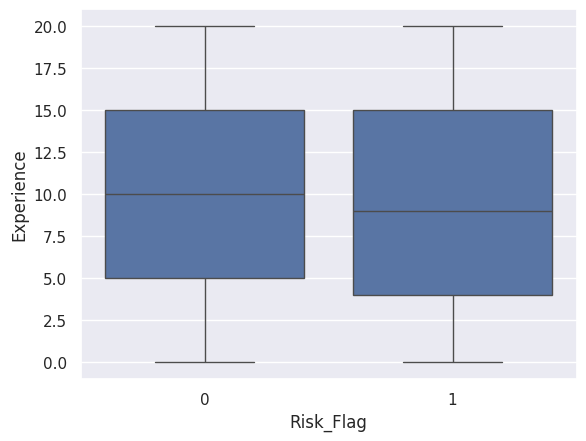

In [ ]:
# Create a boxplot to visualize the distribution of "Experience" based on "Risk_Flag"
sns.boxplot(x="Risk_Flag", y="Experience", data=data)


**Points:**

1.	Utilizes sns.boxplot() function to create a boxplot.
2.	Specifies the "Risk_Flag" column as the x-axis and the "Experience" column as the y-axis.
3.	Uses the DataFrame data as the data source.



<Axes: xlabel='Risk_Flag', ylabel='CURRENT_JOB_YRS'>

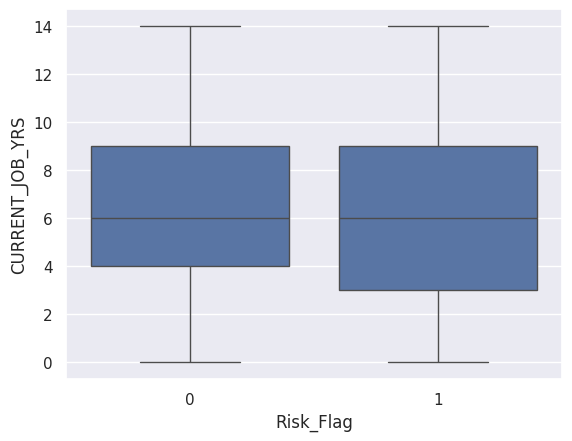

In [ ]:
# Create a boxplot to visualize the distribution of "CURRENT_JOB_YRS" based on "Risk_Flag"
sns.boxplot(x="Risk_Flag", y="CURRENT_JOB_YRS", data=data)


**Points:**

1.	Utilizes sns.boxplot() function to create a boxplot.
2.	Specifies the "Risk_Flag" column as the x-axis and the "CURRENT_JOB_YRS" column as the y-axis.
3.	Uses the DataFrame data as the data source.



<Axes: xlabel='Risk_Flag', ylabel='CURRENT_HOUSE_YRS'>

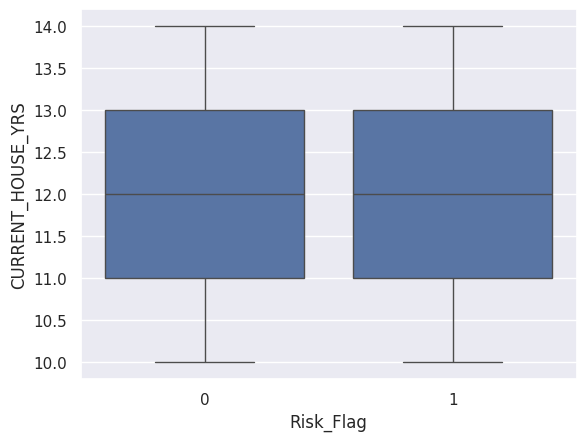

In [ ]:
# Create a boxplot to visualize the distribution of "CURRENT_HOUSE_YRS" based on "Risk_Flag"
sns.boxplot(x="Risk_Flag", y="CURRENT_HOUSE_YRS", data=data)


**Points:**

1.	Utilizes sns.boxplot() function to create a boxplot.
2.	Specifies the "Risk_Flag" column as the x-axis and the "CURRENT_HOUSE_YRS" column as the y-axis.



<Axes: xlabel='House_Ownership', ylabel='count'>

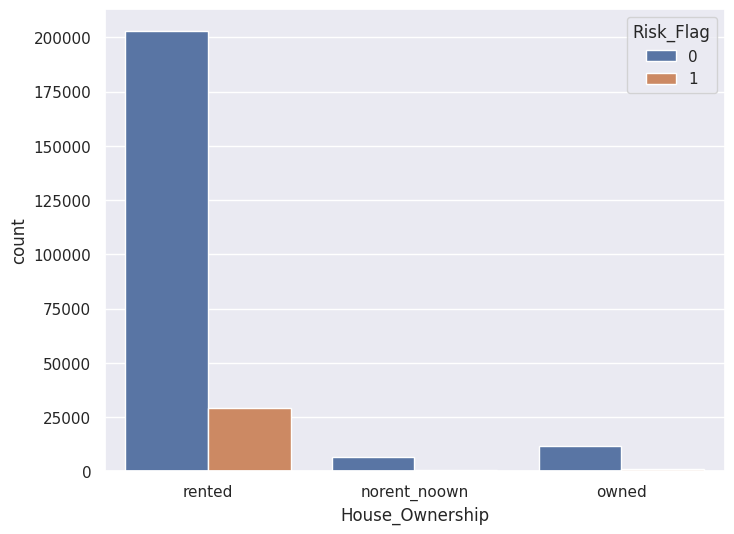

In [ ]:
# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(8, 6))

# Create a count plot to visualize the count of each category in "House_Ownership" column, colored by "Risk_Flag"
sns.countplot(x='House_Ownership', hue='Risk_Flag', ax=ax, data=data)


<Axes: xlabel='Car_Ownership', ylabel='count'>

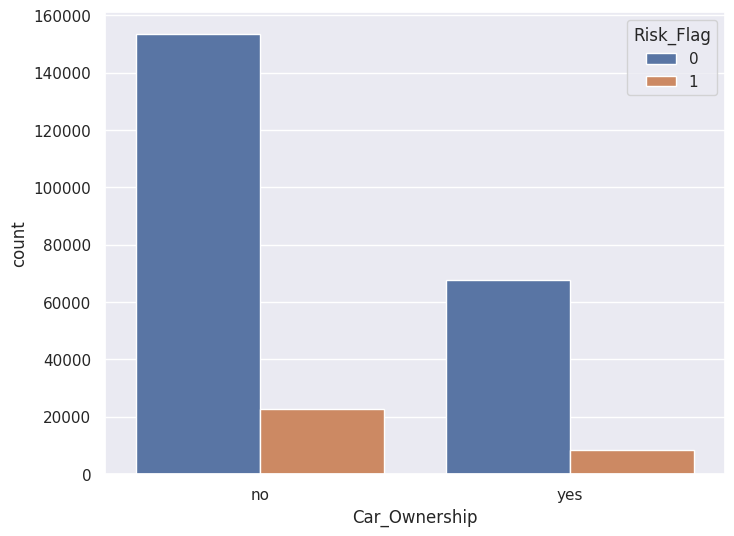

In [ ]:
fig, ax = plt.subplots( figsize = (8,6) )
sns.countplot(x='Car_Ownership', hue='Risk_Flag', ax=ax, data=data)

**Points:**

1.	Utilizes plt.subplots() function to create a figure and axis object with specified size.
2.	Utilizes sns.countplot() function to create a count plot.
3.	Specifies "House_Ownership" column as the x-axis and "Risk_Flag" as the hue to distinguish categories by.
4.	Uses the DataFrame data as the data source.



<Axes: xlabel='Married/Single', ylabel='count'>

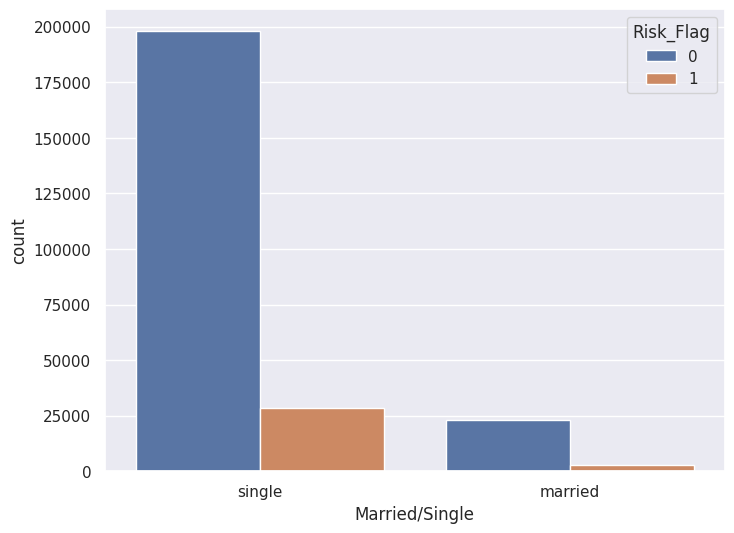

In [ ]:
# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(8, 6))

# Create a count plot to visualize the count of each category in "Married/Single" column, colored by "Risk_Flag"
sns.countplot(x='Married/Single', hue='Risk_Flag', data=data)


Points:
1.	Utilizes plt.subplots() function to create a figure and axis object with specified size.
2.	Utilizes sns.countplot() function to create a count plot.
3.	Specifies "Married/Single" column as the x-axis and "Risk_Flag" as the hue to distinguish categories by.
4.	Uses the DataFrame data as the data source.



<Axes: xlabel='Risk_Flag', ylabel='CURRENT_JOB_YRS'>

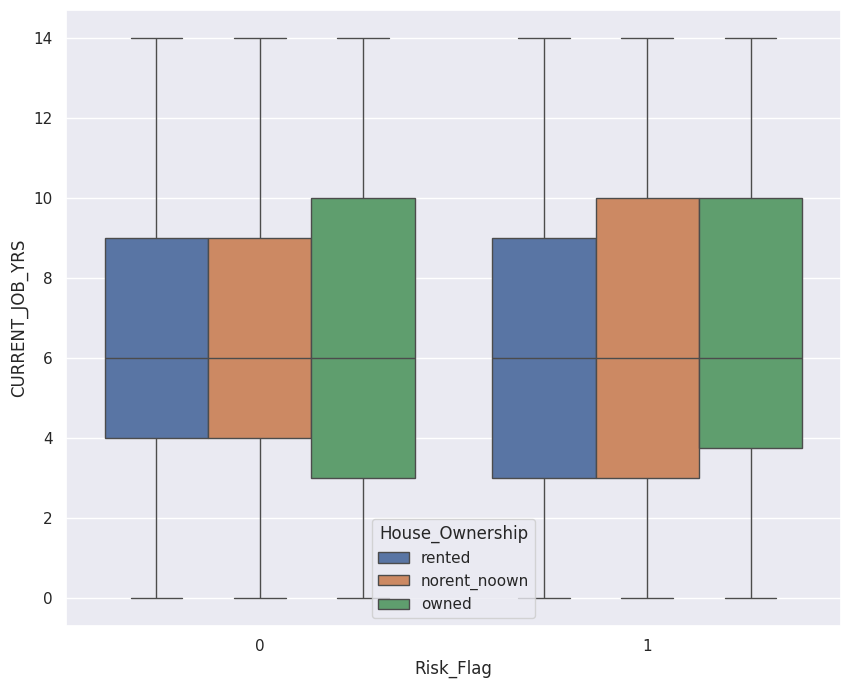

In [ ]:
# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(10, 8))

# Create a boxplot to visualize the distribution of "CURRENT_JOB_YRS" based on "Risk_Flag" and colored by "House_Ownership"
sns.boxplot(x="Risk_Flag", y="CURRENT_JOB_YRS", hue='House_Ownership', data=data)


**Points:**

1.	Utilizes plt.subplots() function to create a figure and axis object with specified size.
2.	Utilizes sns.boxplot() function to create a boxplot.
3.	Specifies "Risk_Flag" column as the x-axis, "CURRENT_JOB_YRS" column as the y-axis, and "House_Ownership" as the hue to distinguish categories by.
4.	Uses the DataFrame data as the data source.



# Feature Engineering

The following encoding will be done to the categorical features:

marital_status, car_ownership – binarise

house_ownership – one-hot

profession, city, state – count encoding

In [ ]:
# Install the category_encoders package to encode categorical variables
!pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 2.6 MB/s eta 0:00:00


Add this line at the beginning of your Colab notebook, and it will install the 'category_encoders' library for you.

In [ ]:
# Import necessary modules for encoding categorical variables
from sklearn.preprocessing import LabelEncoder  # For label encoding
from sklearn.preprocessing import OneHotEncoder  # For one-hot encoding
import category_encoders as ce  # For using advanced encoding techniques

In [ ]:
# Display concise summary of the DataFrame
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [ ]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Iterate over specified columns and perform label encoding
for col in ['Married/Single', 'Car_Ownership']:
    data[col] = label_encoder.fit_transform(data[col])


**Points:**

1.	Initializes a LabelEncoder object.
2.	Iterates over the specified columns ('Married/Single', 'Car_Ownership').
3.	Performs label encoding on each column using the fit_transform() method of the LabelEncoder object.
4.	Modifies the DataFrame data in place by replacing the original categorical values with the encoded values.



In [ ]:
# Initialize OneHotEncoder with sparse=False to get dense array output
onehot_encoder = OneHotEncoder(sparse=False)

# Reshape the 'House_Ownership' column to a 2D array
# and apply one-hot encoding to create binary columns for each category
data['House_Ownership'] = onehot_encoder.fit_transform(data['House_Ownership'].values.reshape(-1, 1))


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


**Points:**
1.	Initializes a OneHotEncoder object with sparse=False to get dense array output.
2.	Reshapes the 'House_Ownership' column to a 2D array as OneHotEncoder expects a 2D array.
3.	Applies one-hot encoding to the reshaped array, creating binary columns for each category.
4.	Updates the 'House_Ownership' column in the DataFrame data with the encoded values.



In [ ]:
# Define the list of high cardinality features
high_card_features = ['Profession', 'CITY', 'STATE']

# Initialize CountEncoder
count_encoder = ce.CountEncoder()

# Transform the high cardinality features, rename the columns with the _count suffix, and join to the original dataframe
count_encoded = count_encoder.fit_transform(data[high_card_features])
data = data.join(count_encoded.add_suffix("_count"))


**Points:**

1.	Defines a list of high cardinality features including 'Profession', 'CITY', and 'STATE'.
2.	Initializes a CountEncoder object.
3.	Transforms the high cardinality features using the CountEncoder.
4.	Renames the columns with the "_count" suffix.
5.	Joins the transformed features back to the original dataframe.



In [ ]:
# Display the first few rows of the DataFrame to inspect changes
data.head()


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Profession_count,CITY_count,STATE_count
0,1,1303834,23,3,1,0.0,0,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0,5217,798,14122
1,2,7574516,40,10,1,0.0,0,Software_Developer,Parbhani,Maharashtra,9,13,0,5053,849,25562
2,3,3991815,66,4,0,0.0,0,Technical_writer,Alappuzha,Kerala,4,10,0,5195,688,5805
3,4,6256451,41,2,1,0.0,1,Software_Developer,Bhubaneswar,Odisha,2,12,1,5053,607,4658
4,5,5768871,47,11,1,0.0,0,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1,4413,809,16537


In [ ]:
# Drop specified columns from the DataFrame
data = data.drop(labels=['Profession', 'CITY', 'STATE'], axis=1)


**Points:**

1.	Uses the drop() method to remove specified columns ('Profession', 'CITY', 'STATE') from the DataFrame.
2.	Specifies axis=1 to indicate column-wise operation.
3.	Updates the DataFrame data without the dropped columns.



In [ ]:
# Display the first few rows of the updated DataFrame after dropping columns
data.head()


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Profession_count,CITY_count,STATE_count
0,1,1303834,23,3,1,0.0,0,3,13,0,5217,798,14122
1,2,7574516,40,10,1,0.0,0,9,13,0,5053,849,25562
2,3,3991815,66,4,0,0.0,0,4,10,0,5195,688,5805
3,4,6256451,41,2,1,0.0,1,2,12,1,5053,607,4658
4,5,5768871,47,11,1,0.0,0,3,14,1,4413,809,16537


# Splitting the data into train and test splits

In [ ]:
# Separate features (x) and target variable (y)
x = data.drop("Risk_Flag", axis=1)  # Features
y = data["Risk_Flag"]  # Target variable


**Points:**

1.	Creates variable x containing features by dropping the "Risk_Flag" column from the DataFrame.
2.	Creates variable y containing the target variable "Risk_Flag".
3.	Uses axis=1 to indicate column-wise operation when dropping the column.



In [ ]:
# Import train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# Use 80% of the data for training and 20% for testing
# Stratify the split based on the target variable y to maintain class distribution
# Set random_state for reproducibility
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=7)


**Points:**

1.	Imports the train_test_split function from sklearn.model_selection.
2.	Splits the dataset into training and testing sets using 80% for training and 20% for testing.
3.	Stratifies the split based on the target variable y to maintain the class distribution in both sets.
4.	Sets random_state to 7 for reproducibility.
5.	Assigns the resulting sets to variables x_train, x_test, y_train, and y_test.



# Random Forest Classifier

In [ ]:
# Import RandomForestClassifier from sklearn.ensemble
from sklearn.ensemble import RandomForestClassifier

# Import SMOTE and Pipeline from imblearn.over_sampling and imblearn.pipeline respectively
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


**These imports serve the following purposes:**

1.	RandomForestClassifier from sklearn.ensemble: This is a machine learning model used for classification tasks. It builds multiple decision trees during training and outputs the class that is the mode of the classes of the individual trees.
2.	SMOTE from imblearn.over_sampling: This is a technique used for dealing with imbalanced datasets by oversampling the minority class. It generates synthetic samples for the minority class to balance the class distribution.
3.	Pipeline from imblearn.pipeline: This is used to chain multiple estimators into one. Pipelines are particularly useful when applying a sequence of transformations to the data followed by a final estimator, as it ensures consistency and makes the code more readable.

Each of these imports serves a specific function in the machine learning workflow, such as model selection, handling class imbalance, and creating data processing pipelines.



In [ ]:
# Initialize a RandomForestClassifier with specified parameters
rf_clf = RandomForestClassifier(criterion='gini', bootstrap=True, random_state=100)

# Initialize SMOTE for oversampling the minority class
smote_sampler = SMOTE(random_state=9)

# Create a pipeline to chain SMOTE and RandomForestClassifier together
pipeline = Pipeline(steps=[['smote', smote_sampler],
                           ['classifier', rf_clf]])

# Fit the pipeline on the training data
pipeline.fit(x_train, y_train)

# Predict the target variable for the testing data
y_pred = pipeline.predict(x_test)


**Points:**

1.	Initializes a RandomForestClassifier with specified parameters (criterion='gini', bootstrap=True, random_state=100).
2.	Initializes SMOTE for oversampling the minority class with random_state=9.
3.	Creates a pipeline to chain SMOTE and RandomForestClassifier together.
4.	Fits the pipeline on the training data (x_train, y_train).
5.	Predicts the target variable for the testing data (x_test).



In [ ]:
# Import necessary metrics from sklearn.metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

# Calculate and print various evaluation metrics
print("-------------------------TEST SCORES-----------------------")
print(f"Recall: {round(recall_score(y_test, y_pred)*100, 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred)*100, 4)}")
print(f"F1-Score: {round(f1_score(y_test, y_pred)*100, 4)}")
print(f"Accuracy score: {round(accuracy_score(y_test, y_pred)*100, 4)}")
print(f"AUC Score: {round(roc_auc_score(y_test, y_pred)*100, 4)}")


-------------------------TEST SCORES-----------------------
Recall: 54.1378
Precision: 54.3306
F1-Score: 54.234
Accuracy score: 88.7619
AUC Score: 73.8778


**Points:**

1.	Imports necessary evaluation metrics from sklearn.metrics.
2.	Calculates and prints various evaluation metrics including Recall, Precision, F1-Score, Accuracy score, and AUC Score.
3.	Uses the round() function to round the scores to four decimal places.



**The evaluation metrics for the model on the test set are as follows:**

1.	Recall: 54.1378%
2.	Precision: 54.3306%
3.	F1-Score: 54.234%
4.	Accuracy score: 88.7619%
5.	AUC Score: 73.8778%

These metrics provide insights into the performance of the model in terms of its ability to correctly classify instances of the positive class (Recall), its ability to avoid misclassifying negative instances as positive (Precision), the balance between Precision and Recall (F1-Score), the overall correctness of the predictions (Accuracy score), and the model's ability to discriminate between positive and negative instances (AUC Score).

These values suggest that while the accuracy score is relatively high, the model's performance in terms of Recall, Precision, F1-Score, and AUC Score may be moderate. Further analysis and tuning may be required to improve the model's performance.



# Summary of ML Task


In [ ]:
# Creating a DataFrame to present information in table format
summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the provided code
summary_table.loc[0] = [1, 'Supervised Learning', 'Classification', 'Risk_Flag', 'Labeled']

# Displaying the information in table format
print(summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


+-----+---------------------+----------------+-----------------+-----------+
| SNo |        Type         |      Task      | Target Variable | Data Type |
+-----+---------------------+----------------+-----------------+-----------+
|  1  | Supervised Learning | Classification |    Risk_Flag    |  Labeled  |
+-----+---------------------+----------------+-----------------+-----------+


In [ ]:
import pandas as pd

# Creating a DataFrame to present information in table format
defaulter_table = pd.DataFrame({
    'SNo': [1, 2],
    'Defaults Yes/No': ['Yes', 'No'],
    'Safety': ['Unsafe', 'Safe'],
    'Category': ['Defaulter', 'Non-Defaulter'],
    'Definition': [
        'Borrower who fails to fulfill their financial obligations, such as paying back a loan, according to the agreed-upon terms.',
        'Borrower who adheres to the terms of the loan agreement and fulfills their financial obligations promptly.'
    ]
})

# Displaying the information in table format
print(defaulter_table.to_markdown(index=False))


|   SNo | Defaults Yes/No   | Safety   | Category      | Definition                                                                                                                 |
|------:|:------------------|:---------|:--------------|:---------------------------------------------------------------------------------------------------------------------------|
|     1 | Yes               | Unsafe   | Defaulter     | Borrower who fails to fulfill their financial obligations, such as paying back a loan, according to the agreed-upon terms. |
|     2 | No                | Safe     | Non-Defaulter | Borrower who adheres to the terms of the loan agreement and fulfills their financial obligations promptly.                 |


In [ ]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2024-12-11 18:49:21 IST+0530**

In [ ]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2024-12-11 18:49:05**

**Last Cell Entry Time: 2024-12-11 18:49:21 IST+0530**

**Time Taken: 0 hour(s), 0 minute(s), and 15 second(s)**

### Q1: What was the purpose of the first cell?

A1: The first cell was used for:
1. Importing necessary libraries for date and time manipulation and display.
2. Tracking the execution time of the first cell.
3. Setting the IST timezone.
4. Displaying a statement indicating the start of initialization and setup.
5. Displaying the current IST time of execution.

### Q2: What was the main goal of this notebook based on the data loaded?

A2: The main goal of this notebook is to predict possible loan defaults using machine learning. The `Risk_Flag` column indicates whether a borrower is likely to default (1 for defaulter, 0 for non-defaulter).

### Q3: What were the initial steps taken to understand the dataset?

A3: The initial steps to understand the dataset involved:
1. Displaying the head of the DataFrame to see the first few rows.
2. Checking the shape (number of rows and columns) of the DataFrame.
3. Displaying the data types of each column and checking for non-null counts using `data.info()`.
4. Checking for missing values using `data.isnull().sum()`.
5. Displaying the column names.

### Q4: How were the numerical features analyzed?

A4: Numerical features were analyzed by:
1. Displaying summary statistics using `data.describe()`.
2. Calculating and displaying the correlation matrix of numerical columns.
3. Displaying histograms for all numerical columns.
4. Counting the value occurrences of the `Risk_Flag` column.
5. Visualizing correlations using a heatmap.

### Q5: How were the categorical features analyzed and handled for modeling?

A5: Categorical features were analyzed by:
1. Creating a function to display value counts and countplots for categorical features (`Married/Single`, `House_Ownership`).
2. Checking the number of unique categories and their counts for high cardinality features (`STATE`, `Profession`).
3. Visualizing the relationship between categorical features (`House_Ownership`, `Car_Ownership`, `Married/Single`) and the `Risk_Flag` using count plots.
4. Visualizing the relationship between a numerical feature (`CURRENT_JOB_YRS`), a categorical feature (`House_Ownership`), and the target variable (`Risk_Flag`) using a boxplot with hue.

### Q6: What feature engineering steps were performed?

A6: Feature engineering steps included:
1. Installing the `category_encoders` library.
2. Importing necessary encoding modules (`LabelEncoder`, `OneHotEncoder`, `category_encoders`).
3. Performing Label Encoding on `Married/Single` and `Car_Ownership`.
4. Attempting One-Hot Encoding on `House_Ownership` (Note: The original code for this step had a FutureWarning).
5. Applying Count Encoding to high cardinality features (`Profession`, `CITY`, `STATE`).
6. Dropping the original high cardinality columns after count encoding.

### Q7: How was the data split for model training and testing?

A7: The data was split into training and testing sets using `train_test_split` with:
1. Features (`x`) by dropping the `Risk_Flag` column.
2. Target variable (`y`) as the `Risk_Flag` column.
3. A test size of 20%.
4. Stratification based on `y` to maintain the proportion of the target variable in both sets.
5. A `random_state` of 7 for reproducibility.

### Q8: Which machine learning model was used and how was class imbalance handled?

A8: A `RandomForestClassifier` was used. Class imbalance was handled by using `SMOTE` (Synthetic Minority Over-sampling Technique) to oversample the minority class. These two steps were chained together in a `Pipeline`.

### Q9: What evaluation metrics were used to assess the model's performance?

A9: The following evaluation metrics were used:
1. Recall
2. Precision
3. F1-Score
4. Accuracy score
5. AUC Score
These were calculated on the test set (`y_test` and `y_pred`).

### Q10: What were the key evaluation scores obtained from the model?

A10: The key evaluation scores on the test set were:
1. Recall: 54.1378%
2. Precision: 54.3306%
3. F1-Score: 54.234%
4. Accuracy score: 88.7619%
5. AUC Score: 73.8778%

### Q11: What type of machine learning task was performed?

A11: The machine learning task performed was **Supervised Learning - Classification**. The target variable was `Risk_Flag`, which is a labeled variable.

### Q12: How are 'Defaulter' and 'Non-Defaulter' defined in this context?

A12:
1. **Defaulter (Risk_Flag = 1):** A borrower who fails to fulfill their financial obligations, such as paying back a loan, according to the agreed-upon terms. Considered 'Unsafe'.
2. **Non-Defaulter (Risk_Flag = 0):** A borrower who adheres to the terms of the loan agreement and fulfills their financial obligations promptly. Considered 'Safe'.

### Q13: What are some potential interview questions based on this notebook and how would you answer them?

A13: Here are some potential interview questions and how to approach answering them:

1.  **Q: What is the business problem you are trying to solve in this notebook?**
    *   **A:** I am building a machine learning model to predict if a loan applicant is likely to default, using historical data with various features like income, age, ownership details, and job information. This helps lenders assess risk before approving loans.

2.  **Q: Can you explain the steps you took for data preprocessing and feature engineering?**
    *   **A:** First, I performed exploratory data analysis (EDA) to understand the data distribution, check for missing values, and analyze relationships between features and the target variable. For categorical features, I used Label Encoding for binary columns (`Married/Single`, `Car_Ownership`) and Count Encoding for high-cardinality features (`Profession`, `CITY`, `STATE`) to convert them into a numerical format suitable for the model. I also attempted One-Hot Encoding for `House_Ownership`.

3.  **Q: Why did you choose Count Encoding for Profession, CITY, and STATE?**
    *   **A:** These columns had a high number of unique categories. One-Hot Encoding would create a very large number of new columns, which can increase dimensionality and potentially lead to the curse of dimensionality and increased training time. Count Encoding replaces each category with the number of times it appears in the dataset, preserving some information about the frequency of each category while reducing dimensionality.

4.  **Q: How did you handle the class imbalance in the dataset? Why is it important to handle class imbalance?**
    *   **A:** I used SMOTE (Synthetic Minority Over-sampling Technique) to handle the class imbalance. SMOTE generates synthetic samples for the minority class (`Risk_Flag` = 1) to balance the class distribution. It's important because an imbalanced dataset can lead to a model that is biased towards the majority class, resulting in poor performance in predicting the minority class (defaulters in this case), which is often the class of interest in risk assessment.

5.  **Q: Why did you use a Pipeline?**
    *   **A:** I used a Pipeline to streamline the workflow by combining the SMOTE oversampling step and the RandomForestClassifier model. This ensures that SMOTE is applied correctly only to the training data during fitting and that the same transformations are implicitly applied to the test data during prediction. It also makes the code cleaner and more reproducible.

6.  **Q: Explain the evaluation metrics you used and what the scores indicate about your model's performance.**
    *   **A:** I used Recall, Precision, F1-Score, Accuracy, and AUC Score.
        *   **Accuracy (88.76%):** The overall percentage of correct predictions. While high, it can be misleading in imbalanced datasets.
        *   **Recall (54.14%):** The model's ability to correctly identify all actual defaulters. A lower recall means the model missed a significant number of actual defaulters (false negatives).
        *   **Precision (54.33%):** The model's ability to avoid misclassifying non-defaulters as defaulters. A lower precision means the model had a significant number of false positives.
        *   **F1-Score (54.23%):** The harmonic mean of Precision and Recall, providing a balanced measure. A moderate F1-score suggests there's room for improvement in balancing false positives and false negatives.
        *   **AUC Score (73.88%):** Measures the model's ability to distinguish between the positive and negative classes. An AUC of 0.7388 is moderate, indicating the model has some discriminative power but isn't perfect.

    The scores indicate that while the model has decent overall accuracy, its ability to correctly identify and classify defaulters (minority class) needs improvement, as shown by the moderate Recall, Precision, F1-Score, and AUC scores.

7.  **Q: What are the limitations of this model and how would you improve it?**
    *   **A:** The current model has moderate performance in identifying loan defaulters. Potential limitations include:
        *   The chosen features might not be the most predictive.
        *   The current model hyperparameter tuning might not be optimal.
        *   SMOTE can sometimes create noisy samples.
    *   To improve the model, I would:
        *   Explore additional feature engineering techniques or create new features.
        *   Perform hyperparameter tuning on the RandomForestClassifier and SMOTE using techniques like GridSearchCV or RandomizedSearchCV.
        *   Experiment with different sampling techniques (e.g., undersampling the majority class, other oversampling methods).
        *   Try other classification algorithms (e.g., Gradient Boosting, Logistic Regression, Support Vector Machines).
        *   Analyze misclassifications to understand patterns in false positives and false negatives.

8.  **Q: Are there any other types of models you would consider for this problem?**
    *   **A:** Yes, besides RandomForest, I would consider:
        *   **Gradient Boosting Models (like XGBoost, LightGBM, CatBoost):** Often perform well on structured data and are robust to various data issues.
        *   **Logistic Regression:** A simpler linear model that can provide a good baseline.
        *   **Support Vector Machines (SVM):** Can be effective but might be computationally expensive on large datasets.
        *   **Neural Networks:** For potentially complex non-linear relationships, although they often require more data and tuning.

9.  **Q: How would you deploy this model?**
    *   **A:** The deployment strategy would depend on the use case. For real-time loan application processing, the model could be deployed as a web service (e.g., using Flask, Django, or cloud platforms like Google Cloud AI Platform, AWS SageMaker) that takes applicant data as input and returns a risk prediction. For batch processing, it could be integrated into a data pipeline. The model object and preprocessing steps (like the trained encoders and SMOTE parameters) would need to be saved and loaded for deployment.

10. **Q: How would you monitor the model's performance in production?**
    *   **A:** Monitoring is crucial. I would track key metrics over time, such as:
        *   Model accuracy, precision, recall, and F1-score on new data.
        *   Data drift (changes in the distribution of input features).
        *   Concept drift (changes in the relationship between features and the target variable).
        *   The proportion of predicted defaulters vs. actual defaulters.
        *   System metrics like latency and throughput.
    Setting up alerts for significant drops in performance or changes in data distribution is important for proactive maintenance.

## Top Interview Questions and Answers based on this Notebook

Here are some key interview questions and straightforward answers based on the content and task performed in this notebook:

*   **Q: What is this notebook primarily about?**
    *   **A:** This notebook focuses on building a machine learning model to predict possible loan defaults. It involves data loading, exploration, preprocessing, feature engineering, and model training and evaluation.

*   **Q: What specifically does the model in this notebook predict?**
    *   **A:** The model predicts the `Risk_Flag`, which indicates whether a loan applicant is likely to be a defaulter (Risk_Flag = 1) or a non-defaulter (Risk_Flag = 0).

*   **Q: What are some sample use cases for this type of prediction?**
    *   **A:**
        *   **Loan Approval:** Banks and financial institutions can use this to assess the risk of lending money to an applicant.
        *   **Credit Scoring:** It can contribute to building a credit scoring system to evaluate an individual's creditworthiness.
        *   **Risk Management:** Helps in managing financial risk by identifying potential defaults early on.
        *   **Setting Interest Rates:** Potentially used to determine appropriate interest rates based on the predicted risk level.

*   **Q: Can you give real-world examples of services or products that use this concept?**
    *   **A:**
        *   **Credit Bureaus (like CIBIL, Equifax, TransUnion):** They collect financial data to generate credit scores, which are used by lenders to assess default risk.
        *   **Banks and Lending Platforms:** Use internal risk assessment models, often powered by machine learning, to decide on loan applications and terms.
        *   **Fintech Companies:** Many financial technology companies offering loans or credit products employ similar predictive models.
        *   **Online Payment Gateways:** May use risk models to detect potentially fraudulent transactions or assess user risk.

*   **Q: What specific machine learning task was performed here?**
    *   **A:** This is a **Supervised Learning Classification** task. The goal is to classify applicants into one of two categories: Defaulter or Non-Defaulter, based on labeled historical data.

*   **Q: Why did you need to handle class imbalance in this dataset?**
    *   **A:** The dataset had significantly fewer defaulters (minority class) than non-defaulters (majority class). Without handling this imbalance, a model could become biased towards the majority class and perform poorly in identifying the crucial minority class (defaulters).

*   **Q: How did you handle the class imbalance?**
    *   **A:** I used SMOTE (Synthetic Minority Over-sampling Technique) to create synthetic samples for the minority class (`Risk_Flag` = 1) in the training data, balancing the class distribution before training the model.

*   **Q: What were the key evaluation metrics you looked at, and why are they important for this problem?**
    *   **A:** I looked at Recall, Precision, F1-Score, Accuracy, and AUC Score.
        *   **Recall:** Important because it tells us how many actual defaulters the model correctly identified (minimizing false negatives).
        *   **Precision:** Important because it tells us how many of the predicted defaulters were actually defaulters (minimizing false positives).
        *   **F1-Score:** A balance between Recall and Precision.
        *   **Accuracy:** Overall correct predictions (less reliable on imbalanced data alone).
        *   **AUC Score:** Measures the model's ability to distinguish between classes.
        For loan default prediction, minimizing false negatives (missing actual defaulters) is often very important, making Recall a critical metric, while Precision helps control the cost of false positives (denying loans to good applicants).

*   **Q: Based on the evaluation scores (e.g., Recall around 54%), what can you say about the model's performance and potential next steps?**
    *   **A:** The current model has moderate performance in identifying defaulters. While accuracy is high due to the dataset imbalance, the Recall score of around 54% indicates it's missing a significant number of actual defaulters. Next steps would involve exploring more advanced feature engineering, hyperparameter tuning of the model and SMOTE, trying different algorithms, and potentially gathering more data or exploring alternative sampling strategies to improve the ability to correctly identify defaulters.

*   **Q: You used Count Encoding for some features. Why not One-Hot Encoding for those?**
    *   **A:** Features like 'Profession', 'CITY', and 'STATE' have a high number of unique categories (high cardinality). One-Hot Encoding them would create a very large number of new columns, increasing the dimensionality significantly. Count Encoding is a way to handle this by replacing categories with their frequency, reducing the number of features while retaining some information about category prevalence.